In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
PROJECT_ROOT = r"D:\TrustXAI"

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "ready",
    "TrustXAI_Balanced.csv"
)

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models"
)

RESULT_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

print("Paths Ready.")

Paths Ready.


In [3]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(49115, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.97.125.160-55110-443-6,104.97.125.160,443.0,192.168.10.5,55110.0,6.0,7/7/2017 3:33,318.0,3.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,192.168.10.5-104.97.125.160-55110-443-6,192.168.10.5,55110.0,104.97.125.160,443.0,6.0,7/7/2017 3:32,63552406.0,7.0,2.0,...,20.0,77777.0,0.0,77777.0,77777.0,58500000.0,0.0,58500000.0,58500000.0,0
2,192.168.10.12-61.251.165.12-36452-80-6,192.168.10.12,36452.0,61.251.165.12,80.0,6.0,7/7/2017 3:51,135.0,2.0,0.0,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.10.3-192.168.10.5-53-53173-17,192.168.10.5,53173.0,192.168.10.3,53.0,17.0,7/7/2017 3:45,209.0,2.0,2.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,192.168.10.15-64.34.226.87-58732-443-6,64.34.226.87,443.0,192.168.10.15,58732.0,6.0,7/7/2017 3:57,158.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
from sklearn.preprocessing import LabelEncoder

columns_to_remove = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

X = df.drop(
    columns=columns_to_remove + ["Label"],
    errors="ignore"
)

# إعادة ترقيم الفئات لتصبح متتابعة
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Label"])

print("Original Labels:")
print(sorted(df["Label"].unique()))

print("\nEncoded Labels:")
print(np.unique(y))

print("\nNumber of Classes:", len(np.unique(y)))

Original Labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(12), np.int64(14)]

Encoded Labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Number of Classes: 12


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(39292, 80)
(9823, 80)


In [7]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost Ready.")

XGBoost Ready.


In [8]:
print("Training Started...")

xgb_model.fit(X_train, y_train)

print("Training Finished.")

Training Started...
Training Finished.


In [9]:
print("Making Predictions...")

y_pred = xgb_model.predict(X_test)

print("Prediction Completed.")

Making Predictions...
Prediction Completed.


In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("="*50)

Accuracy : 0.9918
Precision: 0.9919
Recall   : 0.9918
F1-Score : 0.9918


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       391
           2       1.00      1.00      1.00      1000
           3       1.00      1.00      1.00      1000
           4       1.00      1.00      1.00      1000
           5       1.00      1.00      1.00      1000
           6       1.00      1.00      1.00      1000
           7       1.00      1.00      1.00      1000
           8       1.00      1.00      1.00      1000
           9       1.00      1.00      1.00      1000
          10       0.88      0.88      0.88       301
          11       0.71      0.72      0.71       131

    accuracy                           0.99      9823
   macro avg       0.96      0.97      0.97      9823
weighted avg       0.99      0.99      0.99      9823



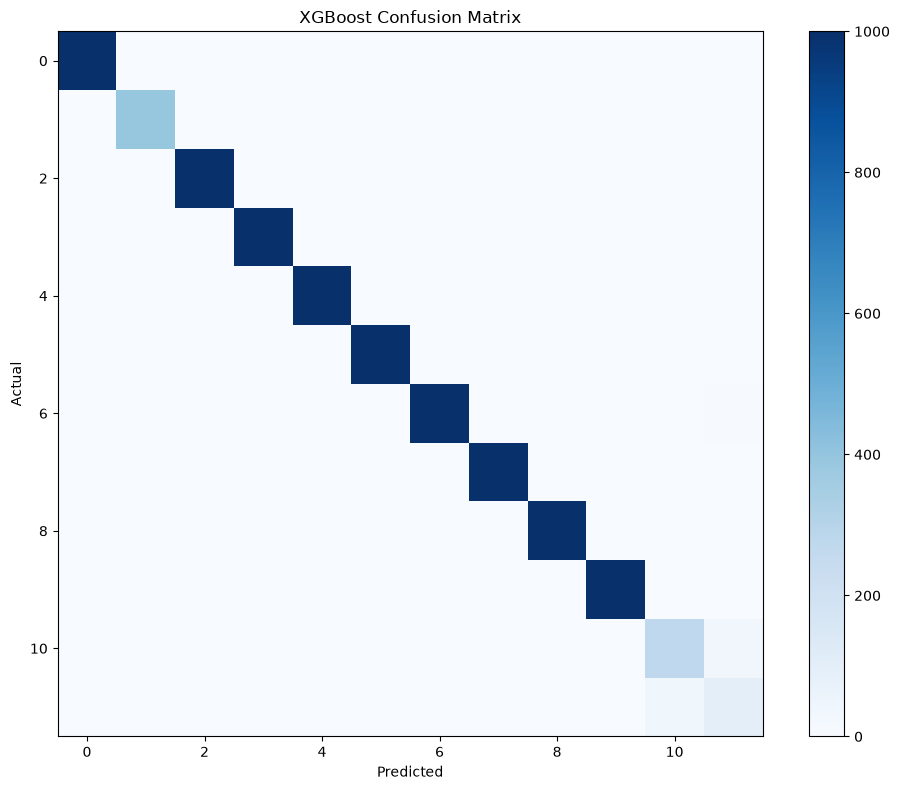

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "XGBoost_ConfusionMatrix.png"
    ),
    dpi=300
)

plt.show()

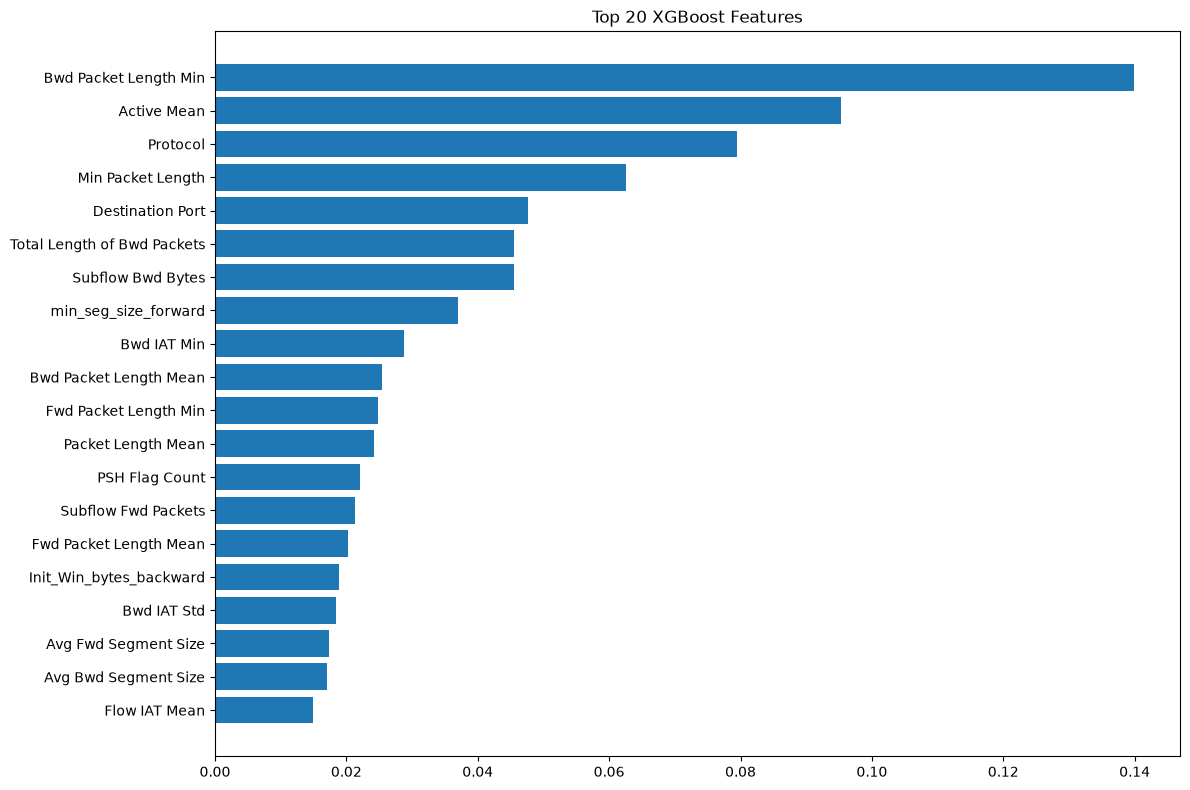

,Feature,Importance
13,Bwd Packet Length Min,0.139905
72,Active Mean,0.095289
2,Protocol,0.079442
40,Min Packet Length,0.062607
1,Destination Port,0.047724
7,Total Length of Bwd Packets,0.045549
67,Subflow Bwd Bytes,0.045465
71,min_seg_size_forward,0.036968
31,Bwd IAT Min,0.028803
14,Bwd Packet Length Mean,0.025393


In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 XGBoost Features")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "XGBoost_FeatureImportance.png"
    ),
    dpi=300
)

plt.show()

importance.head(20)

In [14]:
joblib.dump(
    xgb_model,
    os.path.join(
        MODEL_PATH,
        "XGBoost_TrustXAI.pkl"
    )
)

print("Model Saved Successfully.")

Model Saved Successfully.
